# Loan Interest Rates

This is a practice on the Bondora P2P Loans dataset. Plan is to create a predictive model that predicts interest rate for a person using their profile.
The plan of action here is to do the following:
- Clean up the data a bit.
- Perform some descriptive statistics (mean, median, mode etc)
- Explore data and how it behaves for high risk persons
- More analysis using Confidence intervals (Inferential statistics)
- Use the identified features to train a LR Model

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

from scipy import stats
from math import sqrt

In [2]:
df = pd.read_csv('LoanData.csv')
df.head()

,LoanId,NewCreditCustomer,LoanDate,VerificationType,Age,Gender,Country,AppliedAmount,Amount,Interest,...,EmploymentDurationCurrentEmployer,HomeOwnershipType,IncomeTotal,ExistingLiabilities,LiabilitiesTotal,RefinanceLiabilities,Rating,NoOfPreviousLoansBeforeLoan,AmountOfPreviousLoansBeforeLoan,PreviousEarlyRepaymentsCountBeforeLoan
0,D8EBF360-104C-420F-BEC9-000924E6EFC7,False,2022-09-09,By Bank Statement,27,Female,EE,3189.0,3189.0,35.48,...,UpTo5Years,Other,900.0,0,0.00,0,D,1.0,3402.0,0.0
1,C1A98DDA-5E20-429C-BBFF-0009A05354E0,False,2023-05-19,By Bank Statement,35,Female,FI,4146.0,4146.0,19.86,...,UpTo5Years,Owner,3100.0,0,0.00,0,B,1.0,518.0,0.0
2,9B0B252E-45B9-4172-8E2D-0014A8F18117,False,2024-02-03,By Bank Statement,23,Male,EE,531.0,531.0,19.52,...,UpTo5Years,TenantFurnished,1700.0,0,0.00,0,B,3.0,1593.0,0.0
3,66AE108B-532B-4BB3-BAB7-0019A46412C1,False,2016-03-23,By Bank Statement,53,Female,EE,2125.0,2125.0,20.97,...,MoreThan5Years,Owner,354.0,8,485.09,6,C,1.0,500.0,0.0
4,C7EA512A-465D-4043-A9F2-001B14C3C14E,False,2023-09-26,By Bank Statement,43,Male,FI,414.0,414.0,19.89,...,Other,TenantFurnished,1200.0,0,0.00,0,D,5.0,11198.0,0.0


In [3]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 383382 entries, 0 to 383381
Data columns (total 22 columns):
 #   Column                                  Non-Null Count   Dtype  
---  ------                                  --------------   -----  
 0   LoanId                                  383382 non-null  object 
 1   NewCreditCustomer                       383382 non-null  bool   
 2   LoanDate                                383382 non-null  object 
 3   VerificationType                        383382 non-null  object 
 4   Age                                     383382 non-null  int64  
 5   Gender                                  383382 non-null  object 
 6   Country                                 383382 non-null  object 
 7   AppliedAmount                           383382 non-null  float64
 8   Amount                                  383382 non-null  float64
 9   Interest                                383382 non-null  float64
 10  LoanDuration                            3833

,Age,AppliedAmount,Amount,Interest,LoanDuration,IncomeTotal,ExistingLiabilities,LiabilitiesTotal,RefinanceLiabilities,NoOfPreviousLoansBeforeLoan,AmountOfPreviousLoansBeforeLoan,PreviousEarlyRepaymentsCountBeforeLoan
count,383382.000000,383382.000000,383382.000000,383382.000000,383382.000000,3.833820e+05,383382.000000,3.833820e+05,383382.000000,383382.000000,383382.000000,383382.000000
mean,40.558600,2583.666956,2511.320701,27.286753,50.098948,2.099755e+03,2.724343,4.102211e+02,0.059953,1.947379,3909.228751,0.048036
std,12.186241,2110.743813,2025.724642,18.032004,18.017720,9.599883e+03,2.953641,2.006403e+04,0.519786,3.018998,5712.348664,0.331102
min,18.000000,100.000000,100.000000,6.000000,1.000000,1.000000e-01,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000
25%,31.000000,744.000000,744.000000,18.990000,36.000000,1.100000e+03,1.000000,6.217000e+01,0.000000,0.000000,0.000000,0.000000
50%,39.000000,2125.000000,2125.000000,20.690000,60.000000,1.600000e+03,2.000000,2.500000e+02,0.000000,1.000000,1280.500000,0.000000
75%,49.000000,4146.000000,4146.000000,32.120000,60.000000,2.400000e+03,4.000000,5.037500e+02,0.000000,3.000000,5846.000000,0.000000
max,75.000000,14992.000000,14992.000000,264.310000,120.000000,1.012019e+06,44.000000,1.240000e+07,23.000000,52.000000,119983.000000,19.000000


In [4]:
# Lets set the index to loan ID
df.set_index('LoanId', inplace=True)   
df.index.name

'LoanId'

In [5]:
# We are interested in the interenst column
interest_mean = df['Interest'].mean()
interest_std = df['Interest'].std()

# Number of loans given less the requested amount or applied amount
num_less_amount = len(df[df['Amount'] < df['AppliedAmount']])

rating_proportion = df["Rating"].value_counts()/len(df)

print("Mean Interest Rate:", interest_mean)
print("Standard Deviation of Interest Rate:", interest_std)
print("Number of loans given less than applied amount:", num_less_amount)
print("Proportion of each rating:\n", rating_proportion.sort_index())    


Mean Interest Rate: 27.286753212200885
Standard Deviation of Interest Rate: 18.0320037435147
Number of loans given less than applied amount: 10543
Proportion of each rating:
 Rating
A     0.043291
AA    0.024826
B     0.179124
C     0.317741
D     0.206457
E     0.115707
F     0.074443
HR    0.038411
Name: count, dtype: float64


## High Risk Customer

Now lets identify those that are high risk. these are mostly those who already have a high debt to income ratio


In [6]:
df["DebtToIncome"] = df["Amount"]/df["IncomeTotal"]
df["IsRisky"] = (df["DebtToIncome"] >= 0.35) & (df["EmploymentDurationCurrentEmployer"].isin(["TrialPeriod", "UpTo1Year"]))
risky_proportion = (df[df["IsRisky"] == True]["IsRisky"].value_counts()/len(df)).values[0]

# mean interest for risky vs non risky
mean_interest_risky = df[df["IsRisky"] == True]["Interest"].mean()   
mean_interest_non_risky = df[df["IsRisky"] == False]["Interest"].mean()

print("Proportion of High Risk Customers:", risky_proportion)
print("Mean Interest Rate for High Risk Customers:", mean_interest_risky)
print("Mean Interest Rate for Non-High Risk Customers:", mean_interest_non_risky)

Proportion of High Risk Customers: 0.15878418913772685
Mean Interest Rate for High Risk Customers: 28.859236960985626
Mean Interest Rate for Non-High Risk Customers: 26.98993810987048


Visualizing to determine the viable features for our predictive models.
First lets start with interest and education comparison using a box plot for some descriptive statistics

/tmp/ipykernel_1458597/259711429.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  boxplot_ax = sns.boxplot(y="Education", x="Interest", data=df, palette="colorblind")


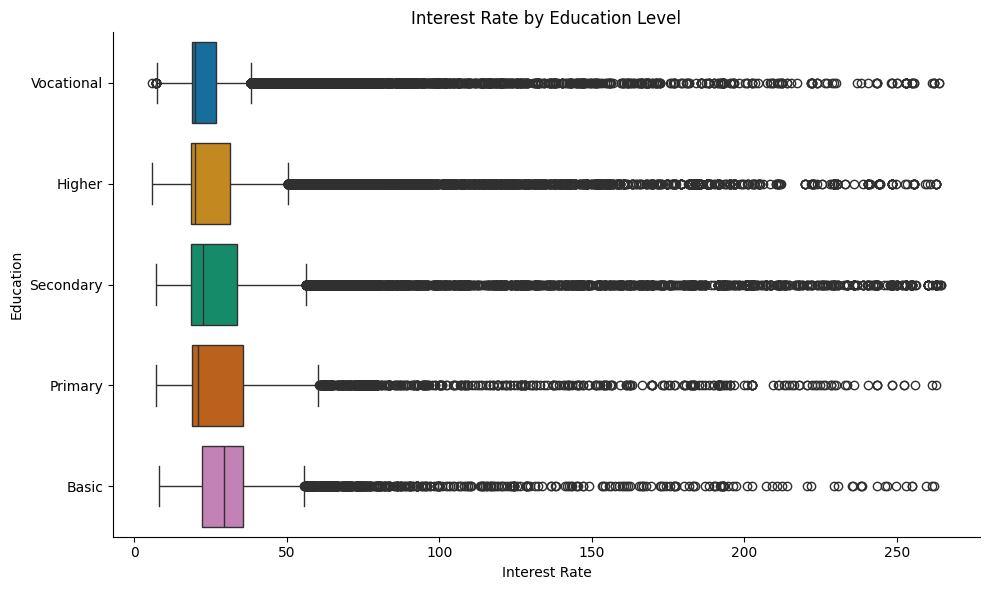

In [7]:
plt.figure(figsize=(10,6))

boxplot_ax = sns.boxplot(y="Education", x="Interest", data=df, palette="colorblind")

boxplot_ax.set_xlabel("Interest Rate")
boxplot_ax.set_title("Interest Rate by Education Level")
sns.despine()


plt.tight_layout()
plt.show()

/tmp/ipykernel_1458597/3747320248.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  boxplot_ax = sns.boxplot(x="NewCreditCustomer", y="Interest", data=df, palette="colorblind")
/tmp/ipykernel_1458597/3747320248.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  boxplot_ax.set_xticklabels(['Existing Customer', 'New Customer'])


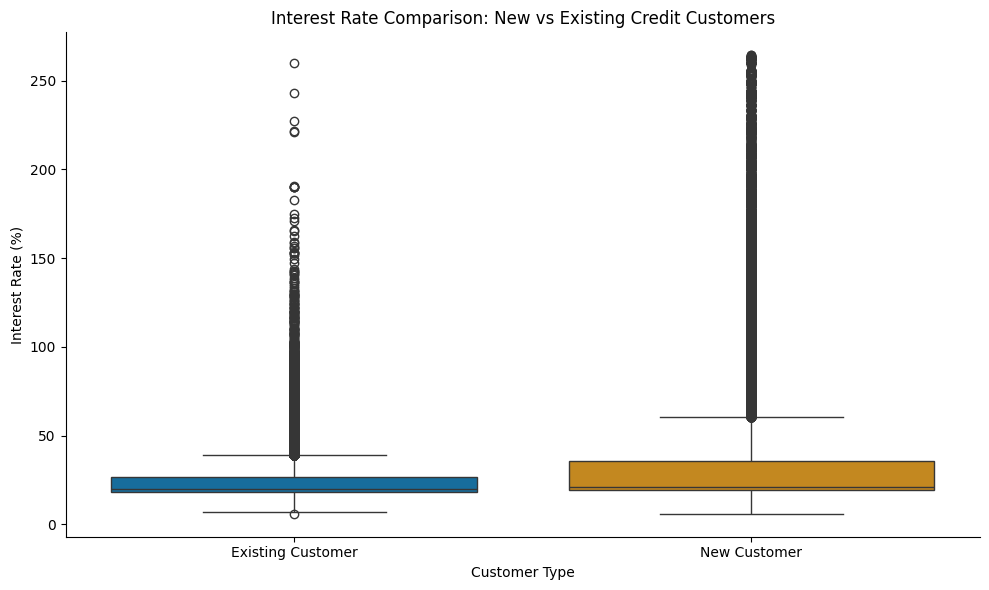

Mean Interest Rate for New Credit Customers: 30.643360713247603
Mean Interest Rate for Existing Customers: 23.643606046430666

Correlation between NewCreditCustomer and Interest: 0.1939


In [8]:
plt.figure(figsize=(10,6))

# Create box plot
boxplot_ax = sns.boxplot(x="NewCreditCustomer", y="Interest", data=df, palette="colorblind")

# Set labels
boxplot_ax.set_xlabel("Customer Type")
boxplot_ax.set_ylabel("Interest Rate (%)")
boxplot_ax.set_title("Interest Rate Comparison: New vs Existing Credit Customers")

# Rename x-axis labels for clarity
boxplot_ax.set_xticklabels(['Existing Customer', 'New Customer'])

sns.despine()
plt.tight_layout()
plt.show()

# Print statistics
print("Mean Interest Rate for New Credit Customers:", 
      df[df["NewCreditCustomer"] == True]["Interest"].mean())
print("Mean Interest Rate for Existing Customers:", 
      df[df["NewCreditCustomer"] == False]["Interest"].mean())
print("\nCorrelation between NewCreditCustomer and Interest:",
      round(df["NewCreditCustomer"].astype(int).corr(df["Interest"]), 4))

/tmp/ipykernel_1458597/1332672230.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  boxplot_ax = sns.boxplot(y="HomeOwnershipType", x="Interest", data=df, palette="colorblind")


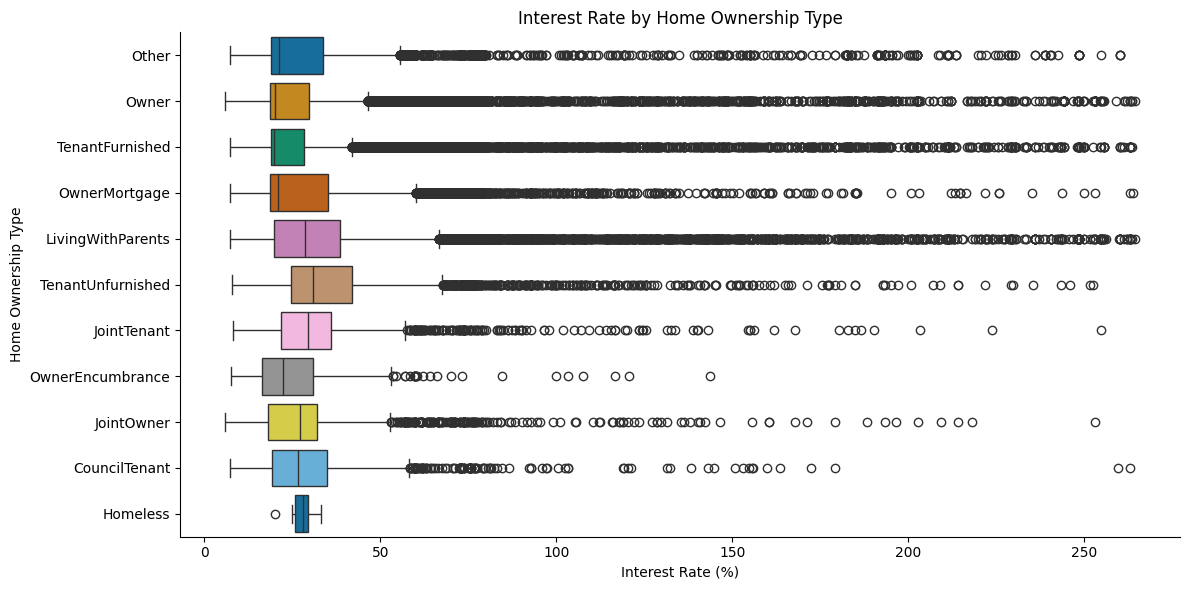


Mean Interest Rate by Home Ownership Type:
HomeOwnershipType
TenantUnfurnished    37.966881
LivingWithParents    34.725373
JointTenant          34.224661
CouncilTenant        29.316516
OwnerMortgage        29.005126
JointOwner           28.734489
Other                27.917908
Homeless             27.333333
TenantFurnished      26.056272
OwnerEncumbrance     25.418364
Owner                25.240593
Name: Interest, dtype: float64


In [14]:
plt.figure(figsize=(12,6))

# Create box plot for HomeOwnershipType
boxplot_ax = sns.boxplot(y="HomeOwnershipType", x="Interest", data=df, palette="colorblind")

# Set labels
boxplot_ax.set_xlabel("Interest Rate (%)")
boxplot_ax.set_ylabel("Home Ownership Type")
boxplot_ax.set_title("Interest Rate by Home Ownership Type")

sns.despine()
plt.tight_layout()
plt.show()

# Print statistics
print("\nMean Interest Rate by Home Ownership Type:")
print(df.groupby("HomeOwnershipType")["Interest"].mean().sort_values(ascending=False))

/tmp/ipykernel_1458597/2479746348.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  boxplot_ax = sns.boxplot(y="EmploymentDurationCurrentEmployer", x="Interest", data=df, palette="colorblind")


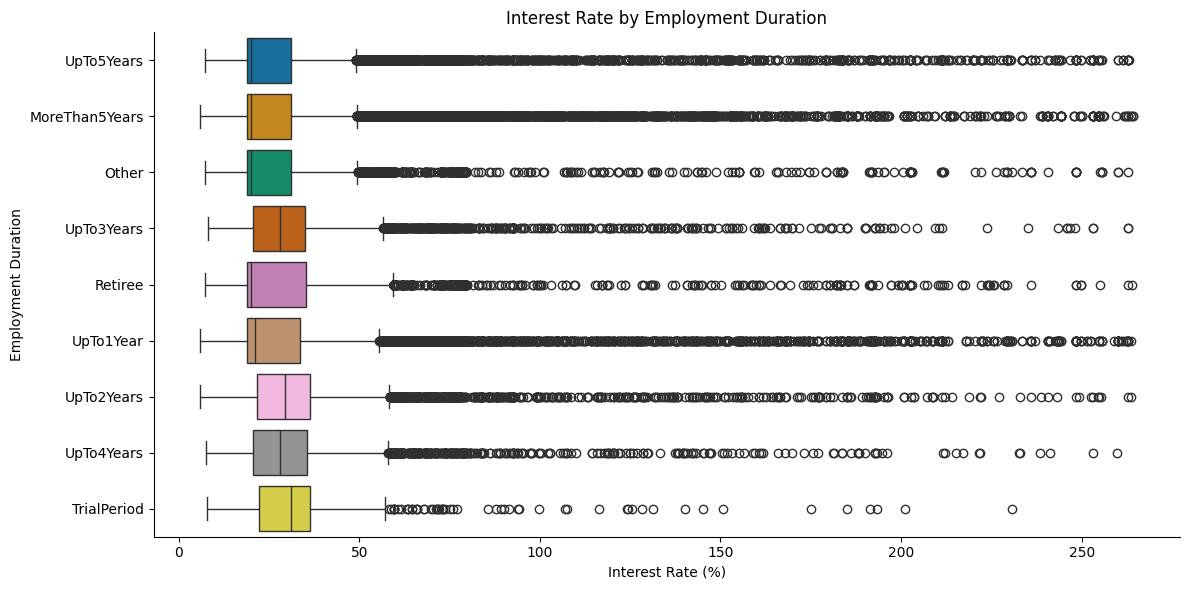


Mean Interest Rate by Employment Duration:
EmploymentDurationCurrentEmployer
UpTo2Years        35.618977
UpTo4Years        34.564023
TrialPeriod       34.030904
UpTo3Years        33.681049
Retiree           28.183222
UpTo1Year         28.153357
MoreThan5Years    26.959821
Other             26.600916
UpTo5Years        26.031692
Name: Interest, dtype: float64


In [15]:
plt.figure(figsize=(12,6))

# Create box plot for EmploymentDurationCurrentEmployer
boxplot_ax = sns.boxplot(y="EmploymentDurationCurrentEmployer", x="Interest", data=df, palette="colorblind")

# Set labels
boxplot_ax.set_xlabel("Interest Rate (%)")
boxplot_ax.set_ylabel("Employment Duration")
boxplot_ax.set_title("Interest Rate by Employment Duration")

sns.despine()
plt.tight_layout()
plt.show()

# Print statistics
print("\nMean Interest Rate by Employment Duration:")
print(df.groupby("EmploymentDurationCurrentEmployer")["Interest"].mean().sort_values(ascending=False))

**Rationale**
Let's choose features and observe their patterns using scatter plots. Candidates are:
- **Loan Duration**: Longer durations typically increase lender risk (more time for default), likely correlating with higher interest rates
- **Income Total**: Higher income suggests better ability to repay, likely correlating with lower interest rates
- **Debt to Income**: Higher ratios indicate more financial burden relative to income, likely correlating with higher interest rates (more risk)
- **Amount of Previous Loans**: Could indicate credit history - may correlate positively (sign of risk) or negatively (sign of creditworthiness)

These are intuitive guesses - let's verify them with correlation analysis.

Correlation between Interest Rate and LoanDuration:
-0.0106
Correlation between Interest Rate and IncomeTotal:
-0.0122
Correlation between Interest Rate and AmountOfPreviousLoansBeforeLoan:
-0.175
Correlation between Interest Rate and DebtToIncome:
-0.0053
Correlation between Interest Rate and LiabilitiesTotal:
0.0039
Correlation between Interest Rate and RefinanceLiabilities:
0.0302


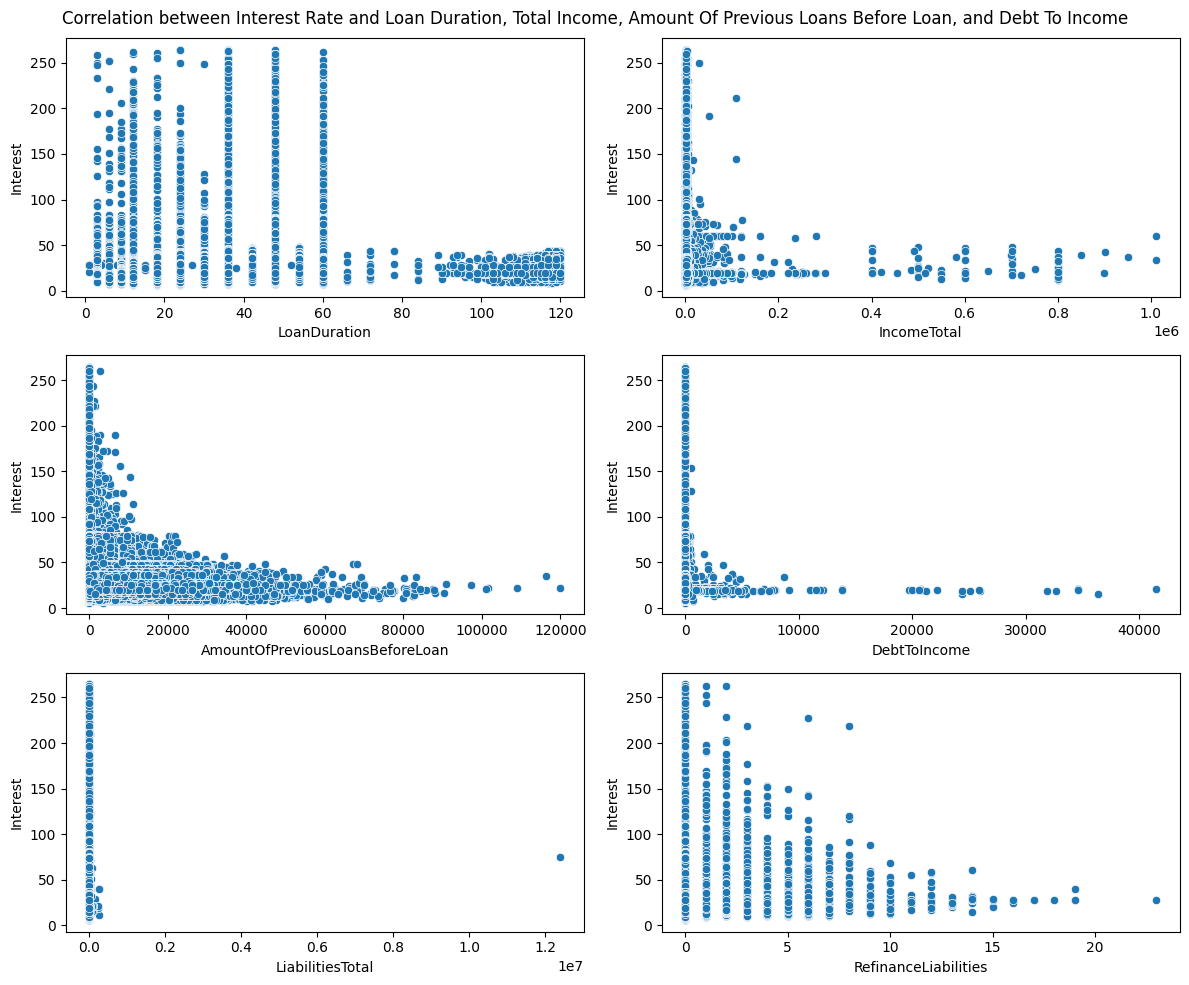

In [9]:

scatterplot_fig = plt.figure(figsize=(12,10))

correlation = []

corr_columns = ["LoanDuration", "IncomeTotal", "AmountOfPreviousLoansBeforeLoan", 
               "DebtToIncome", "LiabilitiesTotal", "RefinanceLiabilities"]


for i in range(0, len(corr_columns)): 

    column_name = corr_columns[i]

    plt.subplot(3, 2, i+1)

    sns.scatterplot(x=column_name, y="Interest", data=df)

    corr = df[column_name].corr(df["Interest"])

    correlation.append(corr)

    print("Correlation between Interest Rate and " + column_name+ ":\n"+ str(round(corr,4))) 

# set the general title
scatterplot_fig.suptitle("Correlation between Interest Rate and Loan Duration, Total Income, Amount Of Previous Loans Before Loan, and Debt To Income")

plt.tight_layout()
plt.show()

In [10]:
num_differences = (df["Amount"] < df["AppliedAmount"]).sum()

n = len(df)

phat = num_differences / n

se = sqrt((phat * (1 - phat)) / n)

confidence_interval = stats.norm.interval(0.95, loc=phat, scale=se)
print("95% Confidence Interval for Proportion of Loans Given Less than Applied Amount:", confidence_interval)

95% Confidence Interval for Proportion of Loans Given Less than Applied Amount: (np.float64(0.02698232853687249), np.float64(0.028017645379482474))


**Observation**
It seems my guess work was wrong the data says the amount of previous loans matters. If the previous loans are payed on time it will mean the person taking the loan is low risk. Lets use this as a predictive constant for out initial Regression model.

In [11]:

X_simple = sm.add_constant(df["AmountOfPreviousLoansBeforeLoan"])

Y_simple = df["Interest"]

model_simple = sm.OLS(Y_simple, X_simple)

results_simple = model_simple.fit()

print(results_simple.summary())

                            OLS Regression Results                            
Dep. Variable:               Interest   R-squared:                       0.031
Model:                            OLS   Adj. R-squared:                  0.031
Method:                 Least Squares   F-statistic:                 1.211e+04
Date:                Thu, 25 Dec 2025   Prob (F-statistic):               0.00
Time:                        00:25:36   Log-Likelihood:            -1.6468e+06
No. Observations:              383382   AIC:                         3.294e+06
Df Residuals:                  383380   BIC:                         3.294e+06
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                                      coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------------
const     

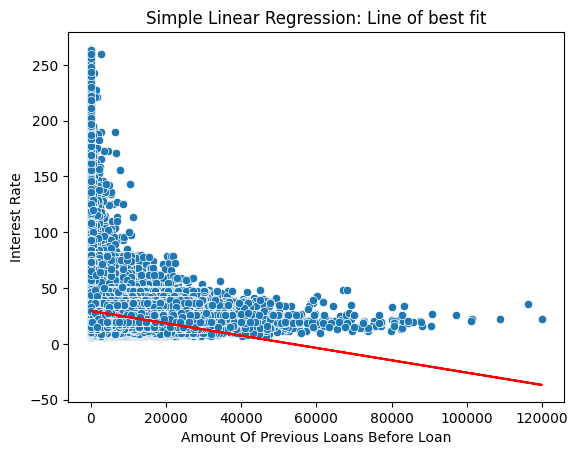

In [12]:
plt.figure()
sns.scatterplot(data=df, x="AmountOfPreviousLoansBeforeLoan", y="Interest")
plt.plot(df["AmountOfPreviousLoansBeforeLoan"], results_simple.predict(X_simple), color="red")
plt.title("Simple Linear Regression: Line of best fit")
plt.xlabel("Amount Of Previous Loans Before Loan")
plt.ylabel("Interest Rate")
plt.show()

Its ok but we need more features for a better predicitve model

In [18]:
predictors = [
    "AmountOfPreviousLoansBeforeLoan",  "Rating" , "Education", "NewCreditCustomer",
]

categorical = ["Rating", "Education",  "NewCreditCustomer"]

# The predictors dataframe. do not forget to add the constant term
X = sm.add_constant(pd.get_dummies(df[predictors], columns=categorical, drop_first=True, dtype=float))

# target variable
Y = df["Interest"]

# create and fit the model
model = sm.OLS(Y, X)
results = model.fit()


print(results.summary())

                            OLS Regression Results                            
Dep. Variable:               Interest   R-squared:                       0.604
Model:                            OLS   Adj. R-squared:                  0.604
Method:                 Least Squares   F-statistic:                 4.501e+04
Date:                Thu, 25 Dec 2025   Prob (F-statistic):               0.00
Time:                        00:37:58   Log-Likelihood:            -1.4751e+06
No. Observations:              383382   AIC:                         2.950e+06
Df Residuals:                  383368   BIC:                         2.950e+06
Df Model:                          13                                         
Covariance Type:            nonrobust                                         
                                      coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------------
const     